# LIME Explanations For Fine-Tuned DistilBERT

This notebook loads the saved ordinal DistilBERT artifacts, reproduces preprocessing, and explains class predictions using LIME.

Saved outputs:
- `results/lime/*.csv` keyword weights and summaries
- `results/lime/*.html` per-sample interactive LIME reports
- `plot/lime_*.png` explanation plots

In [1]:
from pathlib import Path
import json
import re
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PROJECT_ROOT = Path("..").resolve()
DATA_PATH = PROJECT_ROOT / "working_data" / "nhamcs_data_2018_22.csv"
PRED_PATH = PROJECT_ROOT / "working_data" / "nlp_full_logits_probs.csv"
ARTIFACT_DIR = PROJECT_ROOT / "results" / "model_artifacts" / f"distilbert_corn_seed{SEED}"
METADATA_PATH = ARTIFACT_DIR / "metadata.json"
WEIGHTS_PATH = ARTIFACT_DIR / "model_state.pt"
TOKENIZER_DIR = ARTIFACT_DIR / "tokenizer"

RESULTS_DIR = PROJECT_ROOT / "results" / "lime"
PLOT_DIR = PROJECT_ROOT / "plot"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Project root: {PROJECT_ROOT}")
print(f"Artifact metadata exists: {METADATA_PATH.exists()}")
print(f"Model weights exists: {WEIGHTS_PATH.exists()}")
print(f"Tokenizer dir exists: {TOKENIZER_DIR.exists()}")
print(f"Prediction csv exists: {PRED_PATH.exists()}")
print(f"Device: {DEVICE}")

e:\kaggle\traigegeist\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: E:\kaggle\traigegeist
Artifact metadata exists: True
Model weights exists: True
Tokenizer dir exists: True
Prediction csv exists: True
Device: cuda


In [2]:
import importlib
import subprocess
import sys

try:
    lime_text = importlib.import_module("lime.lime_text")
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lime"] )
    lime_text = importlib.import_module("lime.lime_text")

LimeTextExplainer = lime_text.LimeTextExplainer
print("LIME is available.")

LIME is available.


In [11]:
ABBR_MAP = {
    "sob": "shortness of breath",
    "cp": "chest pain",
    "abd": "abdominal",
    "ha": "headache",
    "n/v": "nausea and vomiting",
    "s/p": "status post",
    "w/": "with",
    "w/o": "without",
    "fx": "fracture",
    "lac": "laceration",
    "loc": "loss of consciousness",
    "mva": "motor vehicle accident",
    "uti": "urinary tract infection",
    "uri": "upper respiratory infection",
    "usp": "unspecified",
    "foo": "foot",
    "...": "",
    "oth": "other",
}

# Phrase-level normalization to prevent clinically linked words from splitting in LIME.
# Canonical terms are intentionally underscored so they remain single features.
PHRASE_REPLACEMENTS = [
    (r"\bcardio\s+pulmonary\s+arrest\b", "cardiac_arrest"),
    (r"\bcardiopulmonary\s+arrest\b", "cardiac_arrest"),
    (r"\bcardio\s+respiratory\s+arrest\b", "cardiac_arrest"),
    (r"\bcardiorespiratory\s+arrest\b", "cardiac_arrest"),
    (r"\bcardiac\s+arrest\b", "cardiac_arrest"),
    (r"\bdischarge\s+from\s+ear\b", "ear_discharge"),
    (r"\bear\s+ache\b", "earache"),
    (r"\btemper\s+problems\b", "temper_problems"),
    (r"\bsite\s+unspecified\b", "site_unspecified"),
    (r"\buterine\s+and\s+vaginal\s+bleeding\b", "uterine_vaginal_bleeding"),
    (r"\bvaginal\s+bleeding\b", "vaginal_bleeding"),
]

def concatenate_domain_phrases(text: str) -> str:
    out = str(text)
    for pattern, replacement in PHRASE_REPLACEMENTS:
        out = re.sub(pattern, replacement, out)
    out = re.sub(r"\s+", " ", out).strip()
    return out

def expand_text(text: str) -> str:
    txt = str(text).lower().strip()
    txt = re.sub(r"\s+", " ", txt)

    for k in ["n/v", "s/p", "w/o", "w/"]:
        txt = re.sub(rf"(?<!\w){re.escape(k)}(?!\w)", ABBR_MAP[k], txt)

    for abbr, full in ABBR_MAP.items():
        if "/" in abbr:
            continue
        txt = re.sub(rf"(?<![a-z0-9]){re.escape(abbr)}(?![a-z0-9])", full, txt)

    txt = re.sub(r"[^a-z0-9\s\-\.,_]", " ", txt)
    txt = re.sub(r"\s+", " ", txt).strip()

    # Keep clinically meaningful phrase as one token for LIME stability.
    txt = concatenate_domain_phrases(txt)
    return txt

In [4]:
with METADATA_PATH.open("r", encoding="utf-8") as f:
    metadata = json.load(f)

MODEL_NUM_CLASSES = int(metadata["num_classes"])
MAX_LEN = int(metadata["max_len"])
MODEL_NAME = metadata["model_name"]
DROPOUT = float(metadata.get("dropout", 0.5))
THRESHOLDS = np.asarray(metadata["calibrated_thresholds"], dtype=np.float32)

# 5-class to 3-class merge requested by project update: 1,2->1 and 4,5->3.
CLASS_MERGE_MAP_5_TO_3 = {1: 1, 2: 1, 3: 2, 4: 3, 5: 3}
USE_MERGED_3CLASS_ANALYSIS = MODEL_NUM_CLASSES == 5
ANALYSIS_NUM_CLASSES = 3 if USE_MERGED_3CLASS_ANALYSIS else MODEL_NUM_CLASSES
NUM_CLASSES = ANALYSIS_NUM_CLASSES

def merge_probs_5_to_3(probs: np.ndarray) -> np.ndarray:
    if probs.shape[1] != 5:
        raise ValueError(f"Expected 5 probability columns for merge, got {probs.shape[1]}")
    merged = np.zeros((probs.shape[0], 3), dtype=probs.dtype)
    merged[:, 0] = probs[:, 0] + probs[:, 1]
    merged[:, 1] = probs[:, 2]
    merged[:, 2] = probs[:, 3] + probs[:, 4]
    merged = merged / np.clip(merged.sum(axis=1, keepdims=True), 1e-12, None)
    return merged

def remap_series_5_to_3(series: pd.Series) -> pd.Series:
    return series.map(CLASS_MERGE_MAP_5_TO_3)

class OrdinalBert(nn.Module):
    def __init__(self, model_name: str, num_classes: int = 5, dropout: float = 0.5):
        super().__init__()
        try:
            self.backbone = AutoModel.from_pretrained(model_name, use_safetensors=True)
        except Exception as e:
            raise RuntimeError(
                "Failed to load backbone with safetensors. "
                "This environment blocks .bin checkpoint loading when torch<2.6 "
                "(CVE-2025-32434 mitigation). "
                "Use a model that provides safetensors or upgrade torch to >=2.6."
            ) from e
        hidden = self.backbone.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.ordinal_head = nn.Linear(hidden, num_classes - 1)

    def forward(self, input_ids, attention_mask):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        cls_state = out.last_hidden_state[:, 0]
        return self.ordinal_head(self.dropout(cls_state))

def logits_to_class_probs(logits: torch.Tensor, num_classes: int) -> torch.Tensor:
    cond_probs = torch.sigmoid(logits)
    cum_probs = torch.cumprod(cond_probs, dim=1)

    class_probs = torch.zeros((cum_probs.size(0), num_classes), dtype=cum_probs.dtype, device=cum_probs.device)
    class_probs[:, 0] = 1.0 - cum_probs[:, 0]
    for c in range(1, num_classes - 1):
        class_probs[:, c] = cum_probs[:, c - 1] - cum_probs[:, c]
    class_probs[:, num_classes - 1] = cum_probs[:, num_classes - 2]

    class_probs = torch.clamp(class_probs, min=0.0)
    class_probs = class_probs / class_probs.sum(dim=1, keepdim=True).clamp(min=1e-12)
    return class_probs

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_DIR)
model = OrdinalBert(MODEL_NAME, num_classes=MODEL_NUM_CLASSES, dropout=DROPOUT).to(DEVICE)
state_dict = torch.load(WEIGHTS_PATH, map_location=DEVICE)
model.load_state_dict(state_dict)
model.eval()

print(f"Loaded metadata from: {METADATA_PATH}")
print(f"Loaded weights from: {WEIGHTS_PATH}")
print(f"Model classes in checkpoint: {MODEL_NUM_CLASSES}")
print(f"LIME analysis classes: {ANALYSIS_NUM_CLASSES}")
if USE_MERGED_3CLASS_ANALYSIS:
    print("Applied class merge for analysis: 1,2->1 and 4,5->3")
print(f"Thresholds: {np.round(THRESHOLDS, 4).tolist()}")

Loading weights: 100%|██████████| 101/101 [00:00<00:00, 3606.82it/s]
BertModel LOAD REPORT from: nlpie/distil-clinicalbert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
C:\Users\hp\AppData\Local\Temp\ipykerne

Loaded metadata from: E:\kaggle\traigegeist\results\model_artifacts\distilbert_corn_seed42\metadata.json
Loaded weights from: E:\kaggle\traigegeist\results\model_artifacts\distilbert_corn_seed42\model_state.pt
Model classes in checkpoint: 5
LIME analysis classes: 3
Applied class merge for analysis: 1,2->1 and 4,5->3
Thresholds: [0.4896000027656555, 0.49470001459121704, 0.4959999918937683, 0.5051000118255615]


In [12]:
def predict_proba_texts(texts, batch_size: int = 64) -> np.ndarray:
    texts = [str(t) for t in texts]
    # Re-apply phrase concatenation on perturbed texts generated by LIME.
    texts = [concatenate_domain_phrases(t.lower()) for t in texts]
    all_probs = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        enc = tokenizer(
            batch_texts,
            truncation=True,
            padding=True,
            max_length=MAX_LEN,
            return_tensors="pt",
        )

        with torch.no_grad():
            logits = model(
                input_ids=enc["input_ids"].to(DEVICE),
                attention_mask=enc["attention_mask"].to(DEVICE),
            )
            probs = logits_to_class_probs(logits, MODEL_NUM_CLASSES).cpu().numpy()

            if USE_MERGED_3CLASS_ANALYSIS and MODEL_NUM_CLASSES == 5:
                probs = merge_probs_5_to_3(probs)

        all_probs.append(probs)

    if not all_probs:
        return np.empty((0, ANALYSIS_NUM_CLASSES), dtype=np.float32)

    return np.vstack(all_probs).astype(np.float32)

def predict_label_and_confidence(text: str):
    probs = predict_proba_texts([text])[0]
    pred_class = int(np.argmax(probs) + 1)
    confidence = float(probs[pred_class - 1])
    return pred_class, confidence, probs

In [13]:
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.astype(str).str.strip()

TEXT_COL = "chief_complaint_text"
TARGET_CANDIDATES = ["target_triage_acuity", "triage_acuity", "target"]
target_col = next((c for c in TARGET_CANDIDATES if c in df.columns), None)
if target_col is None:
    raise KeyError(f"Target column not found. Tried {TARGET_CANDIDATES}.")

data = (
    df[[TEXT_COL, target_col]]
    .rename(columns={target_col: "target_triage_acuity"})
    .dropna(subset=[TEXT_COL, "target_triage_acuity"])
    .copy()
)
data["target_triage_acuity"] = data["target_triage_acuity"].astype(int)

if USE_MERGED_3CLASS_ANALYSIS:
    data["target_triage_acuity"] = remap_series_5_to_3(data["target_triage_acuity"])
    data = data.dropna(subset=["target_triage_acuity"]).copy()
    data["target_triage_acuity"] = data["target_triage_acuity"].astype(int)

data["text_clean"] = data["chief_complaint_text"].map(expand_text)
data["row_index"] = data.index

pred_df = None
if PRED_PATH.exists():
    try:
        pred_df = pd.read_csv(PRED_PATH, low_memory=False)
    except Exception as e:
        print(f"Warning: default CSV parse failed for {PRED_PATH}: {e}")
        try:
            pred_df = pd.read_csv(PRED_PATH, engine="python", on_bad_lines="skip")
            print("Loaded prediction CSV with fallback parser (engine='python', on_bad_lines='skip').")
        except Exception as e2:
            print(f"Warning: fallback CSV parse also failed: {e2}")
            pred_df = None

if pred_df is None:
    print("Computing prediction probabilities directly from model outputs.")
    probs = predict_proba_texts(data["text_clean"].tolist(), batch_size=32)
    pred_df = pd.DataFrame({"row_index": data["row_index"].to_numpy()})
    for c in range(ANALYSIS_NUM_CLASSES):
        pred_df[f"prob_class_{c+1}"] = probs[:, c]

if "row_index" not in pred_df.columns:
    pred_df["row_index"] = np.arange(len(pred_df))

pred_df = pred_df.drop_duplicates(subset=["row_index"], keep="first").copy()

prob_cols_existing = [c for c in pred_df.columns if c.startswith("prob_class_")]
prob_cols_existing = sorted(prob_cols_existing, key=lambda x: int(x.split("_")[-1]))

if not prob_cols_existing:
    probs = predict_proba_texts(data["text_clean"].tolist(), batch_size=32)
    pred_df = pd.DataFrame({"row_index": data["row_index"].to_numpy()})
    for c in range(ANALYSIS_NUM_CLASSES):
        pred_df[f"prob_class_{c+1}"] = probs[:, c]
else:
    prob_arr = pred_df[prob_cols_existing].to_numpy(dtype=float)
    if USE_MERGED_3CLASS_ANALYSIS and prob_arr.shape[1] == 5:
        prob_arr = merge_probs_5_to_3(prob_arr)
        pred_df = pred_df[["row_index"]].copy()
        for c in range(ANALYSIS_NUM_CLASSES):
            pred_df[f"prob_class_{c+1}"] = prob_arr[:, c]
    elif prob_arr.shape[1] != ANALYSIS_NUM_CLASSES:
        raise ValueError(
            f"Probability columns mismatch: found {prob_arr.shape[1]}, expected {ANALYSIS_NUM_CLASSES}"
        )

prob_cols = [f"prob_class_{c+1}" for c in range(ANALYSIS_NUM_CLASSES)]
pred_df["pred_class"] = np.argmax(pred_df[prob_cols].to_numpy(dtype=float), axis=1) + 1

required_cols = {"row_index", "pred_class"} | set(prob_cols)
missing = sorted(required_cols - set(pred_df.columns))
if missing:
    raise ValueError(f"Missing required columns in prediction data: {missing}")

merged = pred_df.merge(
    data[["row_index", "chief_complaint_text", "text_clean", "target_triage_acuity"]],
    on="row_index",
    how="inner",
)

# Conservative defaults to avoid kernel crashes on CPU-limited environments.
N_EXPLANATIONS_PER_CLASS = 2
MAX_TOTAL_EXPLANATIONS = 10
selected_frames = []

for cls in range(1, ANALYSIS_NUM_CLASSES + 1):
    class_candidates = merged[merged["pred_class"] == cls].sort_values(
        f"prob_class_{cls}", ascending=False
    ).copy()

    if class_candidates.empty:
        print(f"Warning: no predictions found for class {cls}.")
        continue

    take_n = min(N_EXPLANATIONS_PER_CLASS, len(class_candidates))
    chosen = class_candidates.head(take_n).copy()
    chosen["explain_class"] = cls
    chosen["class_confidence"] = chosen[f"prob_class_{cls}"]
    selected_frames.append(chosen)

if not selected_frames:
    raise ValueError("No predictions found for any class. Cannot run LIME.")

samples_to_explain = pd.concat(selected_frames, ignore_index=True)
samples_to_explain = samples_to_explain.sort_values(
    ["explain_class", "class_confidence"], ascending=[True, False]
).reset_index(drop=True)

if len(samples_to_explain) > MAX_TOTAL_EXPLANATIONS:
    samples_to_explain = (
        samples_to_explain.sort_values("class_confidence", ascending=False)
        .head(MAX_TOTAL_EXPLANATIONS)
        .sort_values(["explain_class", "class_confidence"], ascending=[True, False])
        .reset_index(drop=True)
    )

selection_cols = [
    "explain_class",
    "row_index",
    "chief_complaint_text",
    "target_triage_acuity",
    "pred_class",
    "class_confidence",
]
display(samples_to_explain[selection_cols])

class_counts = samples_to_explain["explain_class"].value_counts().sort_index()
print("Selected rows per class:")
for cls, cnt in class_counts.items():
    print(f"  class {int(cls)}: {int(cnt)}")
print(f"Total rows selected for LIME: {len(samples_to_explain)}")
print(
    f"LIME workload config => N_EXPLANATIONS_PER_CLASS={N_EXPLANATIONS_PER_CLASS}, "
    f"MAX_TOTAL_EXPLANATIONS={MAX_TOTAL_EXPLANATIONS}"
)

,explain_class,row_index,chief_complaint_text,target_triage_acuity,pred_class,class_confidence
0,1,30456,cardiac arrest. labored or difficult breathing...,2,1,0.991268
1,1,21344,cardiac arrest,1,1,0.991060
2,2,22987,"stomach and abdominal pain, cramps an.... low ...",2,2,0.772767
3,2,11916,"abdominal pain, cramps, spasms. uterine and va...",2,2,0.771788
4,3,45029,"earache, pain. discharge from ear. skin rash",3,3,0.890364
5,3,24394,"earache, pain. other special examination",1,3,0.889625


Selected rows per class:
  class 1: 2
  class 2: 2
  class 3: 2
Total rows selected for LIME: 6
LIME workload config => N_EXPLANATIONS_PER_CLASS=2, MAX_TOTAL_EXPLANATIONS=10


In [14]:
import gc

LIME_NUM_FEATURES = 10
LIME_NUM_SAMPLES = 600
LIME_BATCH_SIZE = 32

explainer = LimeTextExplainer(class_names=[str(i) for i in range(1, ANALYSIS_NUM_CLASSES + 1)])

summary_rows = []
all_weight_rows = []
failed_rows = []
prob_cols = [f"prob_class_{i}" for i in range(1, ANALYSIS_NUM_CLASSES + 1)]

for rank, row in samples_to_explain.iterrows():
    text = row["text_clean"]
    row_index = int(row["row_index"])
    explain_class = int(row["explain_class"])
    label_idx = explain_class - 1

    if all(col in row.index for col in prob_cols):
        probs = row[prob_cols].to_numpy(dtype=float)
        pred_class = int(np.argmax(probs) + 1)
        confidence = float(probs[pred_class - 1])
    else:
        pred_class, confidence, probs = predict_label_and_confidence(text)

    try:
        explanation = explainer.explain_instance(
            text_instance=text,
            classifier_fn=lambda x: predict_proba_texts(x, batch_size=LIME_BATCH_SIZE),
            labels=[label_idx],
            num_features=LIME_NUM_FEATURES,
            num_samples=LIME_NUM_SAMPLES,
        )
    except Exception as e:
        failed_rows.append({
            "row_index": row_index,
            "explained_class": explain_class,
            "error": str(e),
        })
        print(f"Skipping row {row_index} (class {explain_class}) due to error: {e}")
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        continue

    feature_weights = explanation.as_list(label=label_idx)
    weight_df_raw = pd.DataFrame(feature_weights, columns=["keyword", "lime_weight"])

    # Keep only features that support the explained class, so no negative bars are plotted.
    weight_df = weight_df_raw[weight_df_raw["lime_weight"] > 0].copy()
    if weight_df.empty:
        weight_df = weight_df_raw.copy()
        weight_df["lime_weight"] = weight_df["lime_weight"].clip(lower=0)

    weight_df = weight_df.sort_values("lime_weight", ascending=False).reset_index(drop=True)
    weight_df["row_index"] = row_index
    weight_df["explained_class"] = explain_class
    weight_df["predicted_class"] = pred_class

    csv_path = RESULTS_DIR / f"lime_keywords_class_{explain_class}_row_{row_index}.csv"
    html_path = RESULTS_DIR / f"lime_explanation_class_{explain_class}_row_{row_index}.html"
    plot_path = PLOT_DIR / f"lime_class_{explain_class}_row_{row_index}_pred_{pred_class}.png"

    weight_df.to_csv(csv_path, index=False)
    explanation.save_to_file(str(html_path))

    plot_df = weight_df.sort_values("lime_weight", ascending=True)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(plot_df["keyword"], plot_df["lime_weight"], color="#0a8f08")
    ax.set_title(f"Local explanation for class {explain_class} (positive-only)")
    ax.set_xlabel("LIME Weight")
    ax.set_ylabel("Keyword")
    fig.suptitle(
        f"LIME explanation | explained class {explain_class} | row {row_index} | predicted {pred_class}",
        y=1.02,
    )
    fig.tight_layout()
    fig.savefig(plot_path, dpi=180, bbox_inches="tight")
    plt.close(fig)

    summary_rows.append({
        "rank": rank + 1,
        "explained_class": explain_class,
        "row_index": row_index,
        "true_class": int(row["target_triage_acuity"]) if pd.notna(row["target_triage_acuity"]) else np.nan,
        "predicted_class": pred_class,
        "predicted_class_probability": confidence,
        "explained_class_probability": float(probs[label_idx]),
        "keywords_csv": str(csv_path),
        "explanation_html": str(html_path),
        "plot_png": str(plot_path),
    })

    all_weight_rows.append(weight_df)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

if not all_weight_rows:
    raise RuntimeError(
        "No LIME explanations were generated. Reduce workload further or inspect failed rows output."
    )

summary_df = pd.DataFrame(summary_rows).sort_values(["explained_class", "rank"]).reset_index(drop=True)
summary_path = RESULTS_DIR / "lime_explanations_summary_all_classes.csv"
summary_df.to_csv(summary_path, index=False)

all_weights_df = pd.concat(all_weight_rows, ignore_index=True)
all_weights_path = RESULTS_DIR / "lime_all_keyword_weights_all_classes.csv"
all_weights_df.to_csv(all_weights_path, index=False)

if failed_rows:
    failed_path = RESULTS_DIR / "lime_failed_rows.csv"
    pd.DataFrame(failed_rows).to_csv(failed_path, index=False)
    print(f"Saved failed row diagnostics: {failed_path}")

display(summary_df)
print(f"Saved summary: {summary_path}")
print(f"Saved all keyword weights: {all_weights_path}")
print(
    f"LIME params => num_features={LIME_NUM_FEATURES}, "
    f"num_samples={LIME_NUM_SAMPLES}, batch_size={LIME_BATCH_SIZE}"
)

,rank,explained_class,row_index,true_class,predicted_class,predicted_class_probability,explained_class_probability,keywords_csv,explanation_html,plot_png
0,1,1,30456,2,1,0.991268,0.991268,E:\kaggle\traigegeist\results\lime\lime_keywor...,E:\kaggle\traigegeist\results\lime\lime_explan...,E:\kaggle\traigegeist\plot\lime_class_1_row_30...
1,2,1,21344,1,1,0.991060,0.991060,E:\kaggle\traigegeist\results\lime\lime_keywor...,E:\kaggle\traigegeist\results\lime\lime_explan...,E:\kaggle\traigegeist\plot\lime_class_1_row_21...
2,3,2,22987,2,2,0.772767,0.772767,E:\kaggle\traigegeist\results\lime\lime_keywor...,E:\kaggle\traigegeist\results\lime\lime_explan...,E:\kaggle\traigegeist\plot\lime_class_2_row_22...
3,4,2,11916,2,2,0.771788,0.771788,E:\kaggle\traigegeist\results\lime\lime_keywor...,E:\kaggle\traigegeist\results\lime\lime_explan...,E:\kaggle\traigegeist\plot\lime_class_2_row_11...
4,5,3,45029,3,3,0.890364,0.890364,E:\kaggle\traigegeist\results\lime\lime_keywor...,E:\kaggle\traigegeist\results\lime\lime_explan...,E:\kaggle\traigegeist\plot\lime_class_3_row_45...
5,6,3,24394,1,3,0.889625,0.889625,E:\kaggle\traigegeist\results\lime\lime_keywor...,E:\kaggle\traigegeist\results\lime\lime_explan...,E:\kaggle\traigegeist\plot\lime_class_3_row_24...


Saved summary: E:\kaggle\traigegeist\results\lime\lime_explanations_summary_all_classes.csv
Saved all keyword weights: E:\kaggle\traigegeist\results\lime\lime_all_keyword_weights_all_classes.csv
LIME params => num_features=10, num_samples=600, batch_size=32


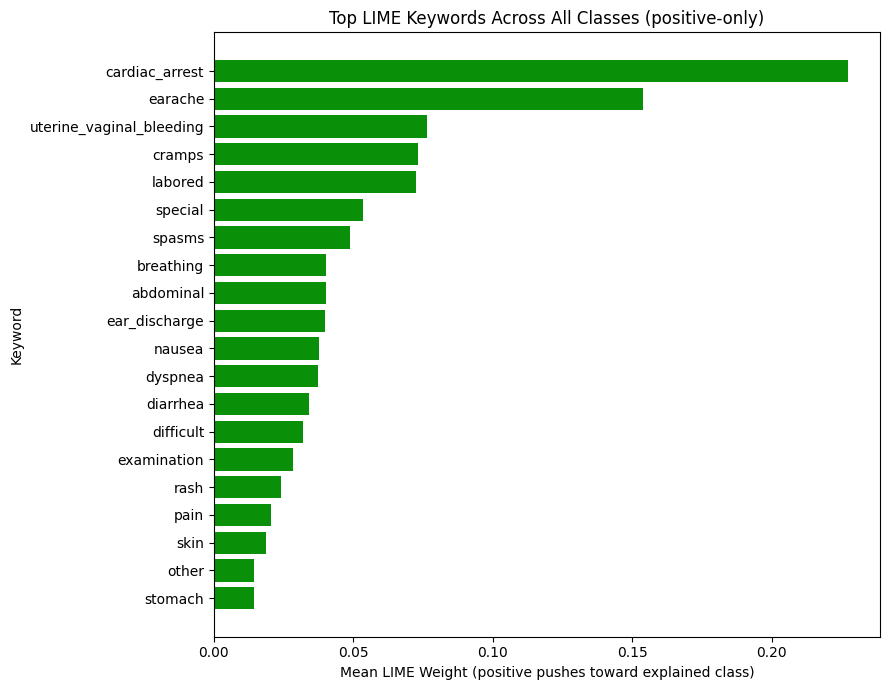

,keyword,mean_weight,mean_abs_weight,count
3,cardiac_arrest,0.227506,0.227506,2
10,earache,0.153912,0.153912,2
22,uterine_vaginal_bleeding,0.076330,0.076330,2
4,cramps,0.073301,0.073301,2
13,labored,0.072617,0.072617,1
20,special,0.053591,0.053591,1
19,spasms,0.048827,0.048827,1
2,breathing,0.040243,0.040243,1
0,abdominal,0.040088,0.040088,2
9,ear_discharge,0.039842,0.039842,1


Saved overall keyword summary: E:\kaggle\traigegeist\results\lime\lime_keyword_summary_top20_all_classes.csv
Saved overall keyword plot: E:\kaggle\traigegeist\plot\lime_keyword_importance_top20_all_classes.png
Saved per-class keyword summary CSVs and positive-only plots in results/lime and plot folders.


In [15]:
# Positive-only aggregation to keep final plots free of negative bars.
positive_weights_df = all_weights_df[all_weights_df["lime_weight"] > 0].copy()
if positive_weights_df.empty:
    raise ValueError("No positive LIME weights found; cannot build positive-only summaries.")

keyword_summary_by_class = (
    positive_weights_df.assign(abs_weight=lambda d: d["lime_weight"].abs())
    .groupby(["explained_class", "keyword"], as_index=False)
    .agg(
        mean_weight=("lime_weight", "mean"),
        mean_abs_weight=("abs_weight", "mean"),
        count=("lime_weight", "size"),
    )
)

overall_keyword_summary = (
    keyword_summary_by_class
    .groupby("keyword", as_index=False)
    .agg(
        mean_weight=("mean_weight", "mean"),
        mean_abs_weight=("mean_abs_weight", "mean"),
        count=("count", "sum"),
    )
    .sort_values("mean_weight", ascending=False)
    .head(20)
)

overall_summary_path = RESULTS_DIR / "lime_keyword_summary_top20_all_classes.csv"
overall_keyword_summary.to_csv(overall_summary_path, index=False)

for cls in range(1, ANALYSIS_NUM_CLASSES + 1):
    cls_df = (
        keyword_summary_by_class[keyword_summary_by_class["explained_class"] == cls]
        .sort_values("mean_weight", ascending=False)
        .head(15)
    )

    if cls_df.empty:
        continue

    cls_path = RESULTS_DIR / f"lime_keyword_summary_class_{cls}_top15.csv"
    cls_df.to_csv(cls_path, index=False)

    cls_plot_df = cls_df.sort_values("mean_weight", ascending=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(cls_plot_df["keyword"], cls_plot_df["mean_weight"], color="#0a8f08")
    ax.set_title(f"Class {cls}: Top LIME Keywords (positive-only)")
    ax.set_xlabel("Mean LIME Weight")
    ax.set_ylabel("Keyword")
    fig.tight_layout()

    cls_plot_path = PLOT_DIR / f"lime_keyword_importance_class_{cls}_top15.png"
    fig.savefig(cls_plot_path, dpi=180, bbox_inches="tight")
    plt.close(fig)

plot_df = overall_keyword_summary.sort_values("mean_weight", ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(plot_df["keyword"], plot_df["mean_weight"], color="#0a8f08")
ax.set_title("Top LIME Keywords Across All Classes (positive-only)")
ax.set_xlabel("Mean LIME Weight (positive pushes toward explained class)")
ax.set_ylabel("Keyword")
fig.tight_layout()

overall_plot_path = PLOT_DIR / "lime_keyword_importance_top20_all_classes.png"
fig.savefig(overall_plot_path, dpi=180, bbox_inches="tight")
plt.show()

display(overall_keyword_summary)
print(f"Saved overall keyword summary: {overall_summary_path}")
print(f"Saved overall keyword plot: {overall_plot_path}")
print("Saved per-class keyword summary CSVs and positive-only plots in results/lime and plot folders.")